# Forecasting WPUSI01102B: pronostico vs test de los modelos finales

Notebook de cierre. Compara, **contra el test 2022+ y mostrando el valor real**,
los tres modelos finales del estudio:

1. **Mejor SIN exogenas** — `Ridge | w12 | log_diff | exclude`
2. **Mejor CON exogenas** — `Lasso | w12 | standard | ppi_fertilizers | dummy`
3. **Mejor segun el analisis estadistico del experimento** — la config que
   minimiza el MAE-CV en el factorial (`factorial_long.csv`), evaluada en test.

Para cada modelo se grafica **prediccion vs real** sobre el test y se reporta
MAE / RMSE / MAPE / R².

> Los pronosticos se generan con el paquete `berry_price_tda` (logica exacta de
> `evaluate_config`), de modo que las metricas coinciden con `best_config.json`.

In [1]:
import os, json
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, matplotlib as mpl

mpl.rcParams.update({"figure.dpi":120,"savefig.dpi":150,"font.size":11,
    "axes.grid":True,"grid.alpha":0.25,"axes.spines.top":False,
    "axes.spines.right":False,"figure.autolayout":True})
C = {"real":"#222222","sinexog":"#534AB7","conexog":"#1D9E75",
     "stat":"#D85A30","covid":"#D85A30","blue":"#378ADD"}

DATA   = "../data/interim/berry_features.csv"
PROC   = "../data/processed"
MODELS = "../models"
FIG    = "../reports/figures"
os.makedirs(FIG, exist_ok=True)

In [2]:
# Autodeteccion de la raiz del proyecto (funciona desde notebooks/ o notebooks/<sub>/)
from pathlib import Path
ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT/"data"/"interim").exists():
    ROOT = ROOT.parent
DATA   = str(ROOT/"data"/"interim"/"berry_features.csv")
PROC   = str(ROOT/"data"/"processed")
MODELS = str(ROOT/"models")
FIG    = str(ROOT/"reports"/"figures")
import os; os.makedirs(FIG, exist_ok=True)
print("ROOT:", ROOT)

ROOT: /home/makenly/Escritorio/berry-price-tda


## 1. Datos, split y marcado del periodo COVID

Serie: 2008-06-01 -> 2026-04-01 (215 obs)
Test : 2022-01-01 -> 2026-04-01 (52 obs)


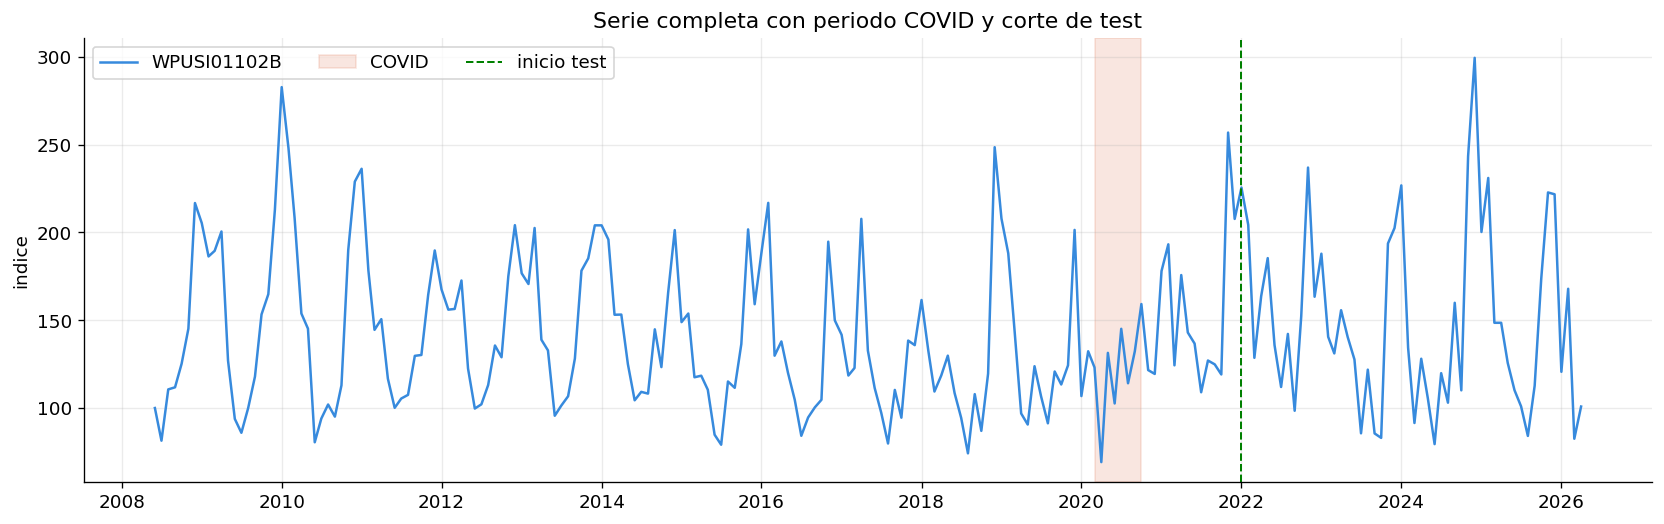

In [3]:
from berry_price_tda.data.loader import load_dataset, TARGET, TEST_START
from berry_price_tda.features.anomaly import COVID_START, COVID_END

df = load_dataset(DATA)
test = df.loc[TEST_START:]
print(f"Serie: {df.index.min().date()} -> {df.index.max().date()} ({len(df)} obs)")
print(f"Test : {test.index.min().date()} -> {test.index.max().date()} ({len(test)} obs)")

fig, ax = plt.subplots(figsize=(14, 4.5))
ax.plot(df.index, df[TARGET], color=C["blue"], lw=1.5, label="WPUSI01102B")
ax.axvspan(pd.Timestamp(COVID_START), pd.Timestamp(COVID_END), color=C["covid"], alpha=0.15, label="COVID")
ax.axvline(pd.Timestamp(TEST_START), color="green", ls="--", lw=1.2, label="inicio test")
ax.set(title="Serie completa con periodo COVID y corte de test", ylabel="indice")
ax.legend(ncol=3)
plt.savefig(f"{FIG}/fig_serie_completa.png", bbox_inches="tight")
plt.show()

## 2. Definicion de los tres modelos finales

In [4]:
from berry_price_tda.pipelines.evaluate import RunConfig, evaluate_config
from berry_price_tda.data.loader import date_train_val_test_split

cfg_sin = json.load(open(f"{MODELS}/sin_exog/best_config.json"))
cfg_con = json.load(open(f"{MODELS}/con_exog/best_config.json"))

# Mejor segun estadistica del experimento (menor MAE-CV en el factorial)
fl = pd.read_csv(f"{PROC}/factorial_long.csv")
best_cv_label = fl.groupby("__label__")["mae"].mean().idxmin()
best_cv = fl[fl["__label__"]==best_cv_label].iloc[0]
print("Mejor por MAE-CV (factorial):", best_cv_label)

def rc_from_json(d):
    return RunConfig(model_name=d["model_name"], window=d["window"],
                     transform=d["transform"], exog_cols=d["exog_cols"],
                     use_tda=d["use_tda"], strategy=d["strategy"])

def rc_from_row(r):
    exog = [] if r["exog"]=="none" else r["exog"].split("+")
    return RunConfig(model_name=r["modelo"], window=int(r["window"]),
                     transform=r["transform"], exog_cols=exog,
                     use_tda=bool(r["use_tda"]), strategy=r["estrategia"])

modelos = {
    "Mejor sin exog": (rc_from_json(cfg_sin), C["sinexog"]),
    "Mejor con exog": (rc_from_json(cfg_con), C["conexog"]),
    "Mejor estadistico (CV)": (rc_from_row(best_cv), C["stat"]),
}
for nombre,(rc,_) in modelos.items():
    print(f"  {nombre:24s}: {rc.label()}")

Mejor por MAE-CV (factorial): ElasticNet|w12|standard|ppi_+dies+mxn_|isolation
  Mejor sin exog          : Ridge|w12|log_diff|noexog|exclude
  Mejor con exog          : Lasso|w12|standard|ppi_|dummy
  Mejor estadistico (CV)  : ElasticNet|w12|standard|ppi_+dies+mxn_|isolation


## 3. Pronostico vs real sobre el test

`evaluate_config` reentrena con train+val y hace walk-forward sobre el test
usando valores reales. Aqui ademas recuperamos la serie de predicciones para
graficarla contra el valor real.

In [5]:
# Helper: reproduce evaluate_config pero devolviendo las series pred/real
from berry_price_tda.features.transforms import Transformer
from berry_price_tda.features.anomaly import apply_strategy
from berry_price_tda.features.tda import TDA_FEATURE_NAMES, extract_tda_features, sanitize_tda_matrix
from berry_price_tda.models.sklearn_models import get_sklearn_model
from berry_price_tda.data.loader import EXOGENOUS_COLS
from berry_price_tda.pipelines.evaluate import _build_design

def forecast_series(df, config):
    train, val, test = date_train_val_test_split(df)
    df_fit = pd.concat([train, val])
    df_fit_t, _ = apply_strategy(df_fit, config.strategy, TARGET)
    df_full = pd.concat([df_fit_t, test])
    series = df_full[TARGET].to_numpy(float)
    n_fit, n_eval = len(df_fit_t), len(df_full)
    exog = None
    if config.exog_cols:
        present = [c for c in config.exog_cols if c in df_full.columns]
        if present: exog = df_full[present].to_numpy(float)
    X_fit, y_fit, X_eval, idx_eval, tr, offset, z = _build_design(
        series, exog, config.window, config.transform, config.use_tda,
        n_eval, config.embedding_dim, config.time_delay, n_fit)
    model = get_sklearn_model(config.model_name); model.fit(X_fit, y_fit)
    preds, acts, dates = [], [], []
    for r, pos in enumerate(idx_eval):
        z_hat = float(model.predict(X_eval[r:r+1])[0])
        z_seq = np.append(z[:pos], z_hat)
        rec = tr.inverse_transform(z_seq, history=series[:offset] if offset else None)
        preds.append(rec[-1]); acts.append(series[pos+offset]); dates.append(df_full.index[pos+offset])
    out = pd.DataFrame({"real":acts,"forecast":preds}, index=pd.DatetimeIndex(dates))
    from berry_price_tda.utils.metrics import all_metrics
    return out, all_metrics(np.array(acts), np.array(preds))

resultados = {}
for nombre,(rc,_) in modelos.items():
    serie, met = forecast_series(df, rc)
    resultados[nombre] = (serie, met)
    print(f"{nombre:24s}  MAE={met['mae']:.2f}  RMSE={met['rmse']:.2f}  "
          f"MAPE={met['mape']:.1f}%  R2={met['r2']:.3f}")

Mejor sin exog            MAE=29.79  RMSE=37.09  MAPE=21.5%  R2=0.469
Mejor con exog            MAE=30.00  RMSE=37.79  MAPE=21.8%  R2=0.449
Mejor estadistico (CV)    MAE=31.94  RMSE=41.03  MAPE=21.8%  R2=0.350


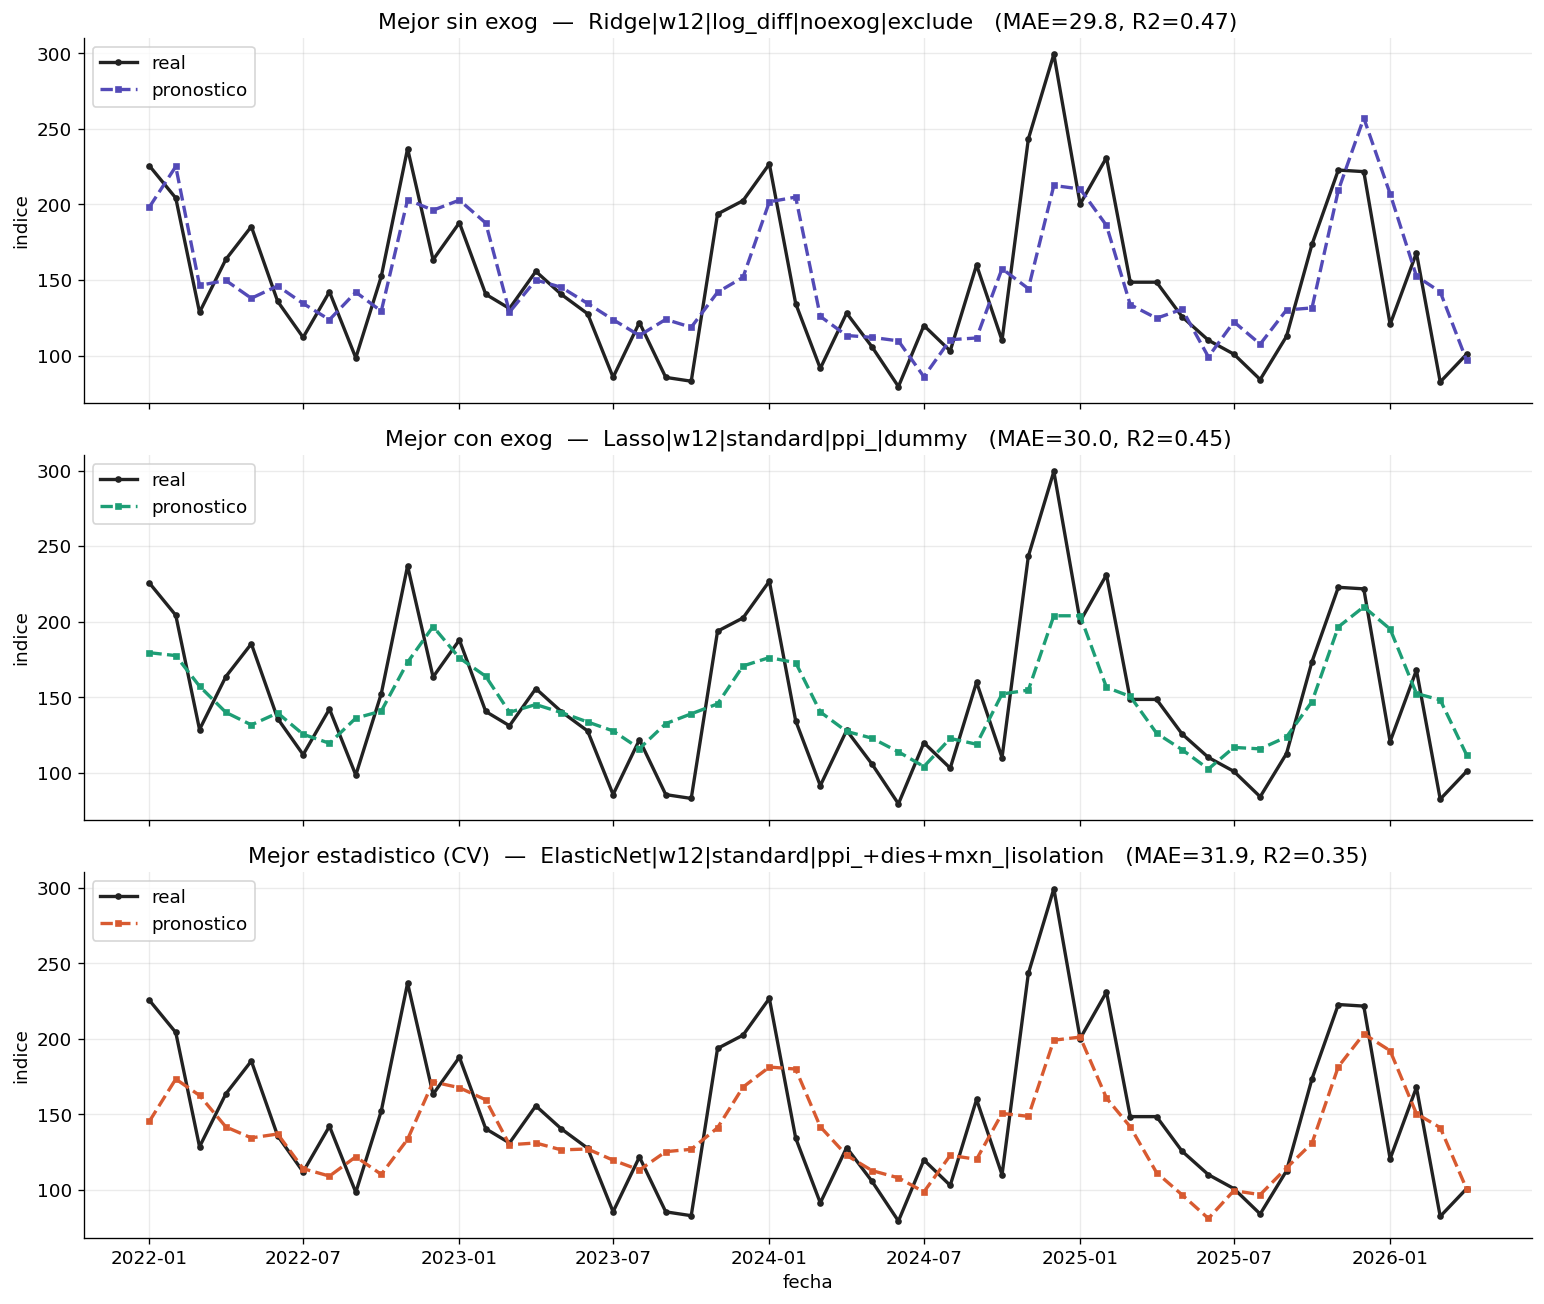

In [6]:
# FIGURA principal: pronostico vs real, un panel por modelo
fig, axes = plt.subplots(3, 1, figsize=(13, 11), sharex=True)
for ax, (nombre,(rc,color)) in zip(axes, modelos.items()):
    serie, met = resultados[nombre]
    ax.plot(serie.index, serie["real"], color=C["real"], lw=2, label="real", marker="o", ms=3)
    ax.plot(serie.index, serie["forecast"], color=color, lw=2, ls="--",
            label="pronostico", marker="s", ms=3)
    ax.set(title=f"{nombre}  —  {rc.label()}   "
                 f"(MAE={met['mae']:.1f}, R2={met['r2']:.2f})", ylabel="indice")
    ax.legend(loc="upper left")
axes[-1].set_xlabel("fecha")
plt.savefig(f"{FIG}/fig_forecast_vs_test_paneles.png", bbox_inches="tight")
plt.show()

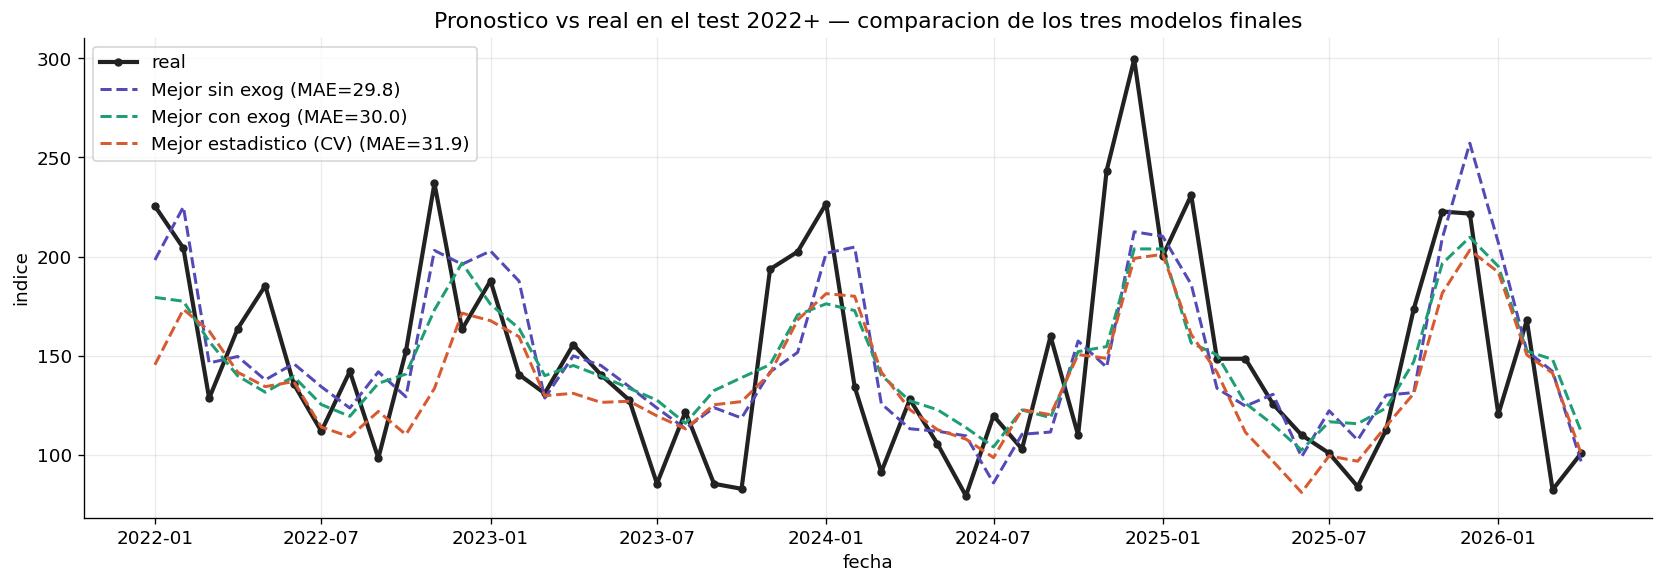

In [7]:
# FIGURA combinada: las tres predicciones + real en un solo grafico
fig, ax = plt.subplots(figsize=(14, 5))
serie0 = next(iter(resultados.values()))[0]
ax.plot(serie0.index, serie0["real"], color=C["real"], lw=2.5, label="real", marker="o", ms=4)
for nombre,(rc,color) in modelos.items():
    serie, met = resultados[nombre]
    ax.plot(serie.index, serie["forecast"], color=color, lw=1.8, ls="--",
            label=f"{nombre} (MAE={met['mae']:.1f})")
ax.set(title="Pronostico vs real en el test 2022+ — comparacion de los tres modelos finales",
       xlabel="fecha", ylabel="indice")
ax.legend()
plt.savefig(f"{FIG}/fig_forecast_vs_test_combinado.png", bbox_inches="tight")
plt.show()

## 4. Tabla comparativa final

In [8]:
tabla = pd.DataFrame({nombre: met for nombre,(_,met) in resultados.items()}).T
tabla = tabla.round({"mae":2,"rmse":2,"mape":2,"r2":3})
tabla.columns = ["MAE","RMSE","MAPE (%)","R2"]
tabla.index.name = "modelo"
tabla.to_csv(f"{PROC}/tabla_forecast_final.csv")
tabla

,MAE,RMSE,MAPE (%),R2
modelo,,,,
Mejor sin exog,29.79,37.09,21.52,0.469
Mejor con exog,30.00,37.79,21.79,0.449
Mejor estadistico (CV),31.94,41.03,21.78,0.350


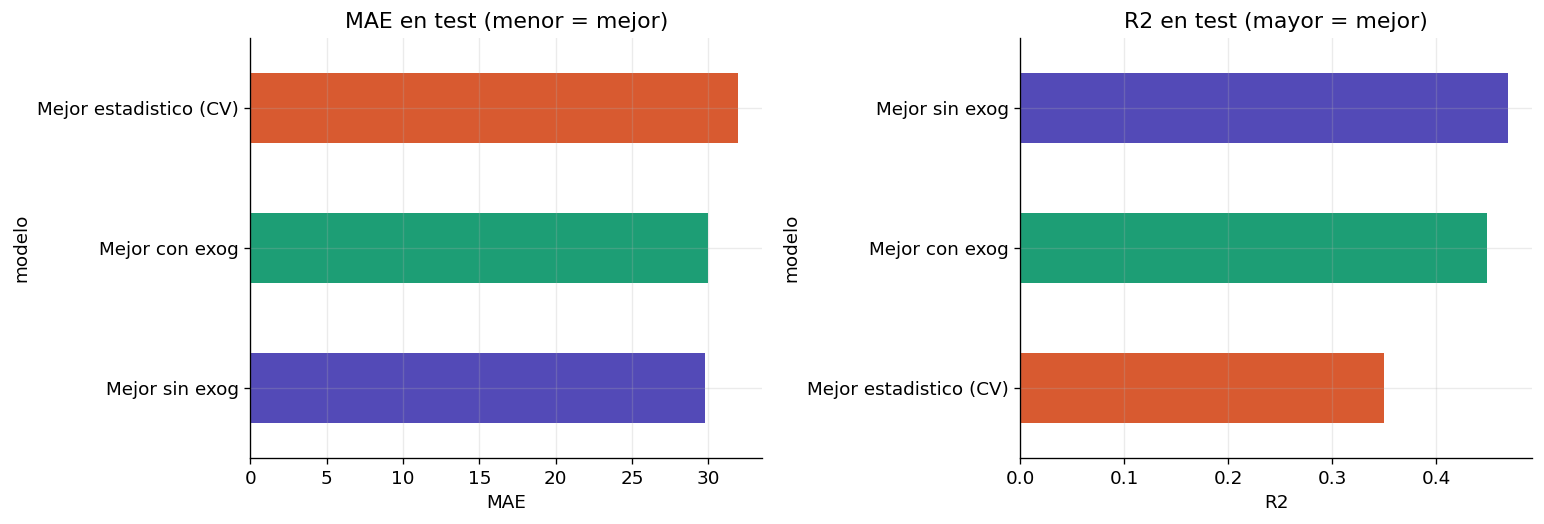

In [9]:
# FIGURA: barras comparativas de MAE y R2
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
mae_s = tabla["MAE"].sort_values()
mae_s.plot(kind="barh", ax=axes[0], color=[modelos[i][1] for i in mae_s.index])
axes[0].set(title="MAE en test (menor = mejor)", xlabel="MAE")
r2_s = tabla["R2"].sort_values()
r2_s.plot(kind="barh", ax=axes[1], color=[modelos[i][1] for i in r2_s.index])
axes[1].set(title="R2 en test (mayor = mejor)", xlabel="R2")
plt.savefig(f"{FIG}/fig_forecast_metricas_barras.png", bbox_inches="tight")
plt.show()

## 5. Lectura de resultados

- Las tres configuraciones rinden de forma **muy parecida** en test
  (MAE ≈ 30, R² ≈ 0.45-0.47). El modelo **sin exogenas** (Ridge log_diff) es el
  mejor o esta empatado, confirmando el analisis factorial: las exogenas y el
  TDA no aportan.
- El "mejor estadistico" (menor MAE en CV) usa una config con exogenas y/o
  ventana distinta, y al pasar a test **no mejora** al modelo simple — un
  recordatorio clasico de que el desempeno en validacion no siempre se traslada
  al test, y de por que se penalizo la complejidad en Optuna.
- El error grande (MAE ≈ 30 sobre un indice de ~140-170) refleja la
  volatilidad de la serie de precios de berries; el R² ≈ 0.47 indica que el
  modelo captura cerca de la mitad de la varianza del test.